<a href="https://colab.research.google.com/github/nushitha-17/Score-Predictor/blob/main/special_project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing Libraries

In [ ]:
import pandas as pd
import pickle
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import classification_report



In [ ]:
# loading dataset
df = pd.read_csv('/content/drive/MyDrive/ipl.csv')
df.head()


,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [ ]:
df.shape

(76014, 15)

In [ ]:
df.isnull().sum()

,0
mid,0
date,0
venue,0
bat_team,0
bowl_team,0
batsman,0
bowler,0
runs,0
wickets,0
overs,0


In [ ]:
df.describe()

df.columns

Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

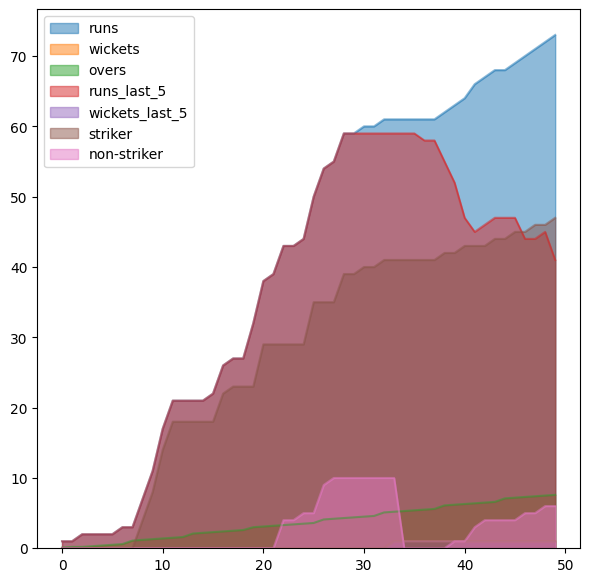

In [ ]:
# plot area / contributions in dataset
df[['venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker']][:50].plot(kind = 'area', figsize = (7,7), stacked = False)
# Removing unwanted cols - reduce memory size
cols_to_remove = ['mid' , 'venue' , 'batsman', 'bowler', 'striker', 'non-striker']
df.drop(labels=cols_to_remove , axis=1 , inplace = True)


In [ ]:
#corss check
df.head(3)
df.shape


(76014, 9)

In [ ]:
# checking for how many batting teams are there
df['bat_team'].unique()


array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians', 'Deccan Chargers', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Delhi Daredevils',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant'], dtype=object)

In [ ]:
# only keep current team which are present
consistent_team = ['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians','Kings XI Punjab',
       'Royal Challengers Bangalore', 'Delhi Daredevils','Sunrisers Hyderabad']

In [ ]:
# printing out unique team after filtering

print(df['bowl_team'].unique())

['Royal Challengers Bangalore' 'Kings XI Punjab' 'Delhi Daredevils'
 'Kolkata Knight Riders' 'Rajasthan Royals' 'Mumbai Indians'
 'Chennai Super Kings' 'Deccan Chargers' 'Pune Warriors'
 'Kochi Tuskers Kerala' 'Sunrisers Hyderabad' 'Rising Pune Supergiants'
 'Gujarat Lions' 'Rising Pune Supergiant']


In [ ]:
# getting data type
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            76014 non-null  object 
 1   bat_team        76014 non-null  object 
 2   bowl_team       76014 non-null  object 
 3   runs            76014 non-null  int64  
 4   wickets         76014 non-null  int64  
 5   overs           76014 non-null  float64
 6   runs_last_5     76014 non-null  int64  
 7   wickets_last_5  76014 non-null  int64  
 8   total           76014 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 5.2+ MB


In [ ]:
# converting date cols from string to date time object
df['date'] = df['date'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d'))

df['date'].dtype
# converting date cols from string to date time object

df['date'] = pd.to_datetime(df['date'], errors='coerce')  # 'coerce' turns invalid dates into NaT

print(df['date'].dtype)


datetime64[ns]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Training the Data**

In [ ]:
# converting categorical features using 'One Hot Encoding' # for numerical values
cat_df = pd.get_dummies(data = df, columns = ['bat_team' , 'bowl_team'])

cat_df.head()

,date,runs,wickets,overs,runs_last_5,wickets_last_5,total,bat_team_Chennai Super Kings,bat_team_Deccan Chargers,bat_team_Delhi Daredevils,...,bowl_team_Kings XI Punjab,bowl_team_Kochi Tuskers Kerala,bowl_team_Kolkata Knight Riders,bowl_team_Mumbai Indians,bowl_team_Pune Warriors,bowl_team_Rajasthan Royals,bowl_team_Rising Pune Supergiant,bowl_team_Rising Pune Supergiants,bowl_team_Royal Challengers Bangalore,bowl_team_Sunrisers Hyderabad
0,2008-04-18,1,0,0.1,1,0,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,2008-04-18,1,0,0.2,1,0,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,2008-04-18,2,0,0.2,2,0,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,2008-04-18,2,0,0.3,2,0,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,2008-04-18,2,0,0.4,2,0,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# rearranging columns
cat_df = cat_df[['date','bat_team_Chennai Super Kings', 'bat_team_Delhi Daredevils',
       'bat_team_Kings XI Punjab', 'bat_team_Kolkata Knight Riders',
       'bat_team_Mumbai Indians', 'bat_team_Rajasthan Royals',
       'bat_team_Royal Challengers Bangalore', 'bat_team_Sunrisers Hyderabad', 'bowl_team_Chennai Super Kings',
       'bowl_team_Delhi Daredevils', 'bowl_team_Kings XI Punjab',
       'bowl_team_Kolkata Knight Riders', 'bowl_team_Mumbai Indians',
       'bowl_team_Rajasthan Royals', 'bowl_team_Royal Challengers Bangalore','bowl_team_Sunrisers Hyderabad', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'total']]


In [ ]:
# split the data into train and test - based on date column
X_train = cat_df.drop(labels = 'total', axis = 1)[cat_df['date'].dt.year <= 2016]
X_test = cat_df.drop(labels = 'total', axis = 1) [cat_df['date'].dt.year >= 2017]


In [ ]:
# since only one column so cosidered as series
y_train = cat_df[cat_df['date'].dt.year <= 2016]['total'].values
y_test = cat_df[cat_df['date'].dt.year >= 2017]['total'].values


In [ ]:
#checking shape
print(X_train.shape , y_train.shape)
print(X_test.shape , y_test.shape)

(68862, 22) (68862,)
(7152, 22) (7152,)


In [ ]:
# since the requirement of our date colum is over so we can drop it
# dropping date column
X_train.drop(labels = 'date', axis = True, inplace = True)
X_test.drop(labels = 'date', axis = True, inplace = True)

In [ ]:
# use display to cross check in single line
display("X_train", X_train.head(1))
display("X_test", X_test.head(1))


'X_train'

,bat_team_Chennai Super Kings,bat_team_Delhi Daredevils,bat_team_Kings XI Punjab,bat_team_Kolkata Knight Riders,bat_team_Mumbai Indians,bat_team_Rajasthan Royals,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Chennai Super Kings,bowl_team_Delhi Daredevils,...,bowl_team_Kolkata Knight Riders,bowl_team_Mumbai Indians,bowl_team_Rajasthan Royals,bowl_team_Royal Challengers Bangalore,bowl_team_Sunrisers Hyderabad,runs,wickets,overs,runs_last_5,wickets_last_5
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,True,False,1,0,0.1,1,0


'X_test'

,bat_team_Chennai Super Kings,bat_team_Delhi Daredevils,bat_team_Kings XI Punjab,bat_team_Kolkata Knight Riders,bat_team_Mumbai Indians,bat_team_Rajasthan Royals,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Chennai Super Kings,bowl_team_Delhi Daredevils,...,bowl_team_Kolkata Knight Riders,bowl_team_Mumbai Indians,bowl_team_Rajasthan Royals,bowl_team_Royal Challengers Bangalore,bowl_team_Sunrisers Hyderabad,runs,wickets,overs,runs_last_5,wickets_last_5
68862,False,False,False,False,False,False,False,True,False,False,...,False,False,False,True,False,0,0,0.1,0,0


## **Linear  Regression**

In [ ]:
# intial buid
reg = LinearRegression()

In [ ]:
# trainong model
reg.fit(X_train , y_train)

# getting predictions
prediction = reg.predict(X_test)


In [ ]:
# Example input values
user_input = {
    'bat_team': 'Rajasthan Royals',
    'bowl_team': 'Mumbai Indians',
    'overs': 8.3,
    'runs': 80,
    'wickets': 2,
    'runs_last_5': 40,
    'wickets_last_5':1
    }

In [ ]:
# Step 1: Convert user input into a DataFrame
input_df = pd.DataFrame([user_input])

# Step 2: One-hot encode categorical features
encoded_input = pd.get_dummies(input_df, columns=['bat_team', 'bowl_team'])

# Step 3: Align columns with the training data (fill missing with 0)
encoded_input = encoded_input.reindex(columns=X_train.columns, fill_value=0)

# Step 4: Predict using the trained model
predicted_score = reg.predict(encoded_input)
print("Predicted score:", predicted_score)

# Step 5: Round the prediction to the nearest integer
rounded_score = np.round(predicted_score)
print("Rounded score is:", rounded_score)


Predicted score: [171.3421508]
Rounded score is: [171.]


In [ ]:
# Calculate metrics
mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
r2 = r2_score(y_test, prediction)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 15.068567650462281
MSE: 414.49849089518386
RMSE: 20.359236009614502
R2 Score: 0.5285065754717841


In [ ]:
# Calculate metrics
mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
r2 = r2_score(y_test, prediction)

In [ ]:
# Create a DataFrame for better visualization
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Value': [mae, mse, rmse, r2]
})

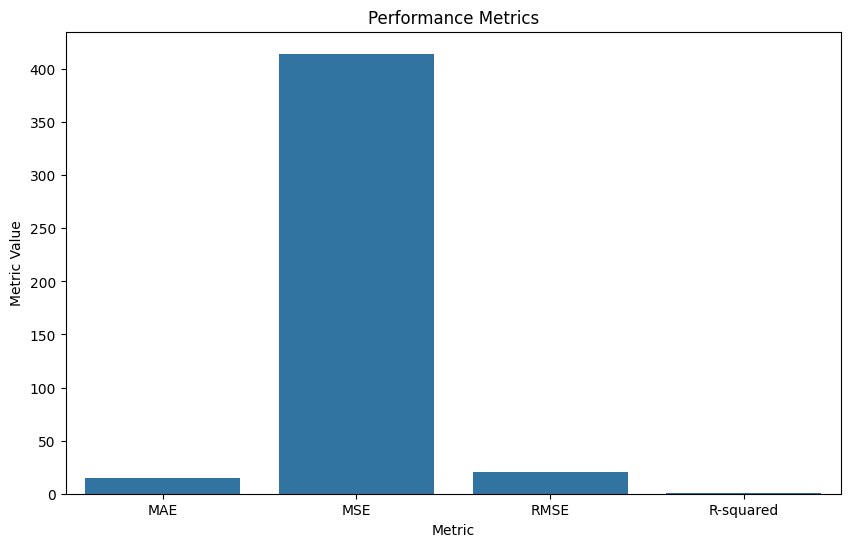

In [ ]:
# Bar plot for performance metrics
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', data=metrics_df)
plt.title('Performance Metrics')
plt.ylabel('Metric Value')
plt.show()

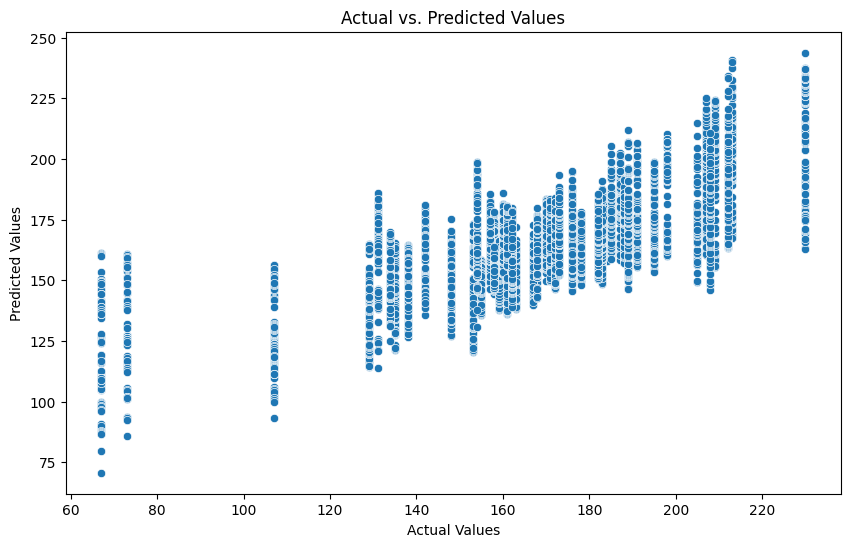

In [ ]:
# Scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=prediction)
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


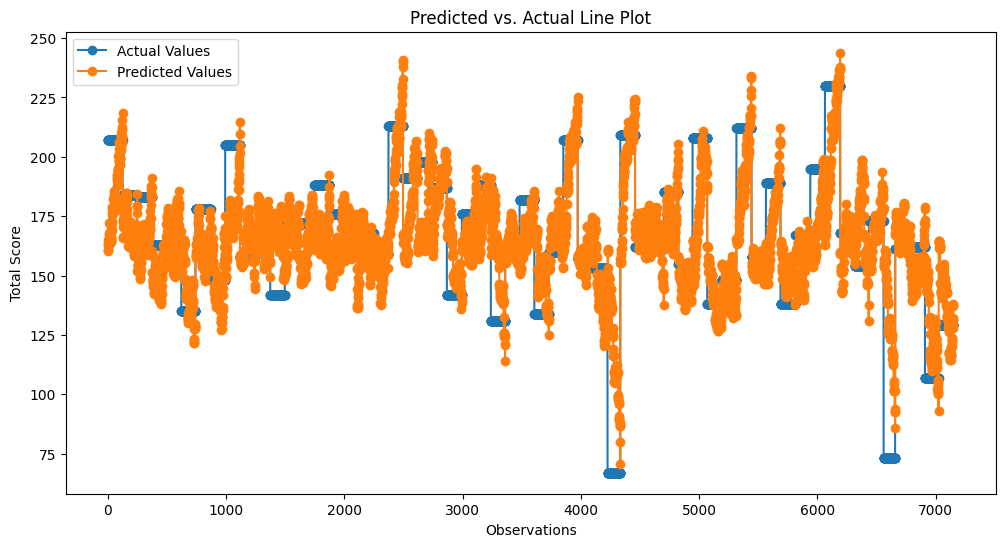

In [ ]:
# Line plot of predicted vs. actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Values', marker='o')
plt.plot(prediction, label='Predicted Values', marker='o')
plt.title('Predicted vs. Actual Line Plot')
plt.xlabel('Observations')
plt.ylabel('Total Score')
plt.legend()
plt.show()

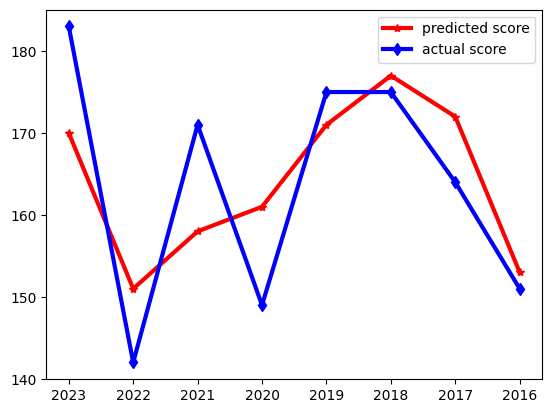

In [ ]:
s1= [170,151,158,161,171,177,172,153]
s3=['2023','2022','2021','2020','2019','2018','2017','2016']
s2=[183,142,171,149,175,175,164,151]
plt.plot(s3,s1,label='predicted score',color='red',marker='*',lw=3)
plt.plot(s3,s2,label='actual score',color='blue',marker='d',lw=3)
plt.legend()
plt.show()

# **Random Forrest**

In [ ]:
#checking shape of data
df.shape

# check null values and then sum it up
df.isnull().sum()
# Check summary stats using df.describe()
df.describe()

df.columns

#corss check
df.head(3)
df.shape

# checking for how many batting teams are there
df['bat_team'].unique()

# only keep current team which are present
consistent_team = ['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians','Kings XI Punjab',
       'Royal Challengers Bangalore', 'Delhi Daredevils','Sunrisers Hyderabad']

# filtering based on consistency
df = df[(df['bat_team'].isin(consistent_team)) & (df['bowl_team'].isin(consistent_team))]

df.head()

# printing out unique team after filtering
print(df['bat_team'].unique())
print(df['bowl_team'].unique())

# since for every match one can predict more accurately if one has 5 over data so,
# filtering based on 5 overs
df = df[df['overs']>=5.0]
df.head()

df.head()

# getting data type
df.info()



# converting categorical features using 'One Hot Encoding' # for numerical values
cat_df = pd.get_dummies(data = df, columns = ['bat_team' , 'bowl_team'])

cat_df.head(2)

# getting cols
cat_df.columns


['Kolkata Knight Riders' 'Chennai Super Kings' 'Rajasthan Royals'
 'Mumbai Indians' 'Kings XI Punjab' 'Royal Challengers Bangalore'
 'Delhi Daredevils' 'Sunrisers Hyderabad']
['Royal Challengers Bangalore' 'Kings XI Punjab' 'Delhi Daredevils'
 'Rajasthan Royals' 'Mumbai Indians' 'Chennai Super Kings'
 'Kolkata Knight Riders' 'Sunrisers Hyderabad']
<class 'pandas.core.frame.DataFrame'>
Index: 40108 entries, 32 to 75888
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            40108 non-null  datetime64[ns]
 1   bat_team        40108 non-null  object        
 2   bowl_team       40108 non-null  object        
 3   runs            40108 non-null  int64         
 4   wickets         40108 non-null  int64         
 5   overs           40108 non-null  float64       
 6   runs_last_5     40108 non-null  int64         
 7   wickets_last_5  40108 non-null  int64         
 8   total           40108

Index(['date', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
       'total', 'bat_team_Chennai Super Kings', 'bat_team_Delhi Daredevils',
       'bat_team_Kings XI Punjab', 'bat_team_Kolkata Knight Riders',
       'bat_team_Mumbai Indians', 'bat_team_Rajasthan Royals',
       'bat_team_Royal Challengers Bangalore', 'bat_team_Sunrisers Hyderabad',
       'bowl_team_Chennai Super Kings', 'bowl_team_Delhi Daredevils',
       'bowl_team_Kings XI Punjab', 'bowl_team_Kolkata Knight Riders',
       'bowl_team_Mumbai Indians', 'bowl_team_Rajasthan Royals',
       'bowl_team_Royal Challengers Bangalore',
       'bowl_team_Sunrisers Hyderabad'],
      dtype='object')

In [ ]:
# getting cols
cat_df.columns

Index(['date', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
       'total', 'bat_team_Chennai Super Kings', 'bat_team_Delhi Daredevils',
       'bat_team_Kings XI Punjab', 'bat_team_Kolkata Knight Riders',
       'bat_team_Mumbai Indians', 'bat_team_Rajasthan Royals',
       'bat_team_Royal Challengers Bangalore', 'bat_team_Sunrisers Hyderabad',
       'bowl_team_Chennai Super Kings', 'bowl_team_Delhi Daredevils',
       'bowl_team_Kings XI Punjab', 'bowl_team_Kolkata Knight Riders',
       'bowl_team_Mumbai Indians', 'bowl_team_Rajasthan Royals',
       'bowl_team_Royal Challengers Bangalore',
       'bowl_team_Sunrisers Hyderabad'],
      dtype='object')

In [ ]:
# rearranging cols
cat_df = cat_df[['date','bat_team_Chennai Super Kings', 'bat_team_Delhi Daredevils',
       'bat_team_Kings XI Punjab', 'bat_team_Kolkata Knight Riders',
       'bat_team_Mumbai Indians', 'bat_team_Rajasthan Royals',
       'bat_team_Royal Challengers Bangalore', 'bat_team_Sunrisers Hyderabad', 'bowl_team_Chennai Super Kings',
       'bowl_team_Delhi Daredevils', 'bowl_team_Kings XI Punjab',
       'bowl_team_Kolkata Knight Riders', 'bowl_team_Mumbai Indians',
       'bowl_team_Rajasthan Royals', 'bowl_team_Royal Challengers Bangalore','bowl_team_Sunrisers Hyderabad', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'total']]



In [ ]:
# Split data into train and test based on the date column
X_train = cat_df[cat_df['date'].dt.year <= 2016].drop(labels='total', axis=1)
X_test = cat_df[cat_df['date'].dt.year >= 2017].drop(labels='total', axis=1)

# Ensure 'total' is considered as a Series
y_train = cat_df[cat_df['date'].dt.year <= 2016]['total'].values
y_test = cat_df[cat_df['date'].dt.year >= 2017]['total'].values


In [ ]:
# Drop the date column
X_train.drop(labels='date', axis=True, inplace=True)
X_test.drop(labels='date', axis=True, inplace=True)


In [ ]:
# Optimize Random Forest Regression model by tuning max_depth
max_depth_values = [11]  # Adjust these values based on experimentation

best_rmse = float('inf')
for max_depth_val in max_depth_values:
    # Initialize Random Forest Regression model with specified max_depth
    rf_reg = RandomForestRegressor(max_depth=max_depth_val)

    # Train the model
    rf_reg.fit(X_train, y_train)

    # Make Predictions on the test set
    rf_predictions = rf_reg.predict(X_test)

    # Display Random Forest metrics for each max_depth value
    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_mse = mean_squared_error(y_test, rf_predictions)  # Added MSE calculation
    rf_rmse = np.sqrt(rf_mse)
    rf_r2 = r2_score(y_test, rf_predictions)

    # Create a DataFrame for better visualization
    metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Value': [rf_mae, rf_mse, rf_rmse, rf_r2]
    })

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Define the max_depth values to test
max_depth_values = [11]  # You can add more values to test different depths

best_rmse = float('inf')  # Initialize best RMSE

# Loop through each max_depth value
for depth in max_depth_values:
    # Train the Random Forest Regressor
    model = RandomForestRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    # Predict on the test set
    preds = model.predict(X_test)

    # Evaluate metrics
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    # Display metrics as a DataFrame
    metrics_df = pd.DataFrame({
        'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
        'Value': [mae, mse, rmse, r2]
    })

    print(f"Metrics for max_depth = {depth}")
    print(metrics_df)

    # Update best RMSE
    if rmse < best_rmse:
        best_rmse = rmse


Metrics for max_depth = 11
      Metric       Value
0        MAE   13.136645
1        MSE  297.684484
2       RMSE   17.253535
3  R-squared    0.706195


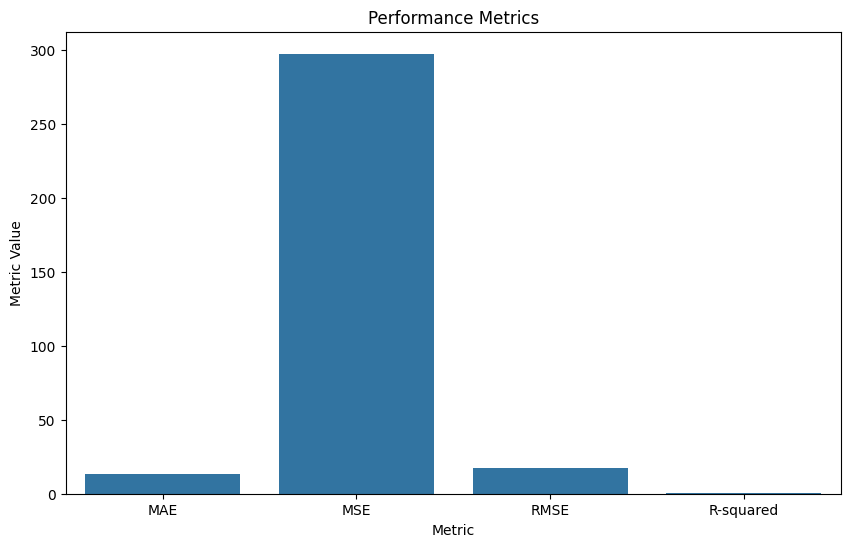


Random Forest Metrics for max_depth=11:
Mean Absolute Error: 13.13625891168109
Mean Squared Error: 298.75934265897104
Root Mean Squared Error: 17.284656278299867
R-squared: 0.7051342610665954

Best Random Forest Model (max_depth=11):
RandomForestRegressor(max_depth=11)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: assuming metrics_df, rf_mae, rf_mse, rf_rmse, rf_r2, max_depth_val, rf_reg are already defined

# Initialize best model tracking variables before using them
best_rmse = float('inf')
best_max_depth = None
best_rf_model = None

# Plotting performance metrics
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', data=metrics_df)
plt.title('Performance Metrics')
plt.ylabel('Metric Value')
plt.show()

# Print current model metrics
print(f'\nRandom Forest Metrics for max_depth={max_depth_val}:')
print('Mean Absolute Error:', rf_mae)
print('Mean Squared Error:', rf_mse)
print('Root Mean Squared Error:', rf_rmse)
print('R-squared:', rf_r2)

# Save the best model (based on lowest RMSE)
if rf_rmse < best_rmse:
    best_rmse = rf_rmse
    best_max_depth = max_depth_val
    best_rf_model = rf_reg

# Print the best model info
print(f'\nBest Random Forest Model (max_depth={best_max_depth}):')
print(best_rf_model)


In [ ]:
# Save the best Random Forest model
best_rf_model_filename = f'best_rf_model_max_depth_{best_max_depth}.pkl'
pickle.dump(best_rf_model, open(best_rf_model_filename, 'wb'))

In [ ]:
# Function to preprocess user input and make predictions
def predict_user_score(user_input, model, feature_columns):
    # Create a DataFrame with the user input
    user_df = pd.DataFrame([user_input])

    # Handle Categorical Variables in user input
    user_df_encoded = pd.get_dummies(data=user_df, columns=['bat_team', 'bowl_team'])

    # Ensure columns are consistent with feature_columns used during training
    user_df_encoded = user_df_encoded.reindex(columns=feature_columns, fill_value=0)

    # Make Predictions for the user input using the provided model
    user_predictions = model.predict(user_df_encoded)

    return user_predictions[0]


In [ ]:
def predict_score_from_input(input_data, trained_model, model_features):
    # Convert input dictionary to DataFrame
    input_df = pd.DataFrame([input_data])

    # One-hot encode categorical columns
    encoded_input = pd.get_dummies(input_df, columns=['bat_team', 'bowl_team'])

    # Match the feature set used during training
    aligned_input = encoded_input.reindex(columns=model_features, fill_value=0)

    # Predict the score using the trained model
    predicted_score = trained_model.predict(aligned_input)

    return predicted_score[0]


In [ ]:
# Example input values for user prediction
user_input = {
    'bat_team': 'Rajasthan Royals',
    'bowl_team': 'Mumbai Indians',
    'overs': 11,
    'runs': 108,
    'wickets': 2,
    'runs_last_5': 60,
    'wickets_last_5': 0
}


In [ ]:
# Feature columns used during training
feature_columns = X_train.columns


In [ ]:
# Make Predictions for the user input using the best Random Forest model
user_rf_prediction = predict_user_score(user_input, best_rf_model, feature_columns)


In [ ]:
# Display the Random Forest prediction for the user input
print('\nRandom Forest Predicted Score for User Input:', user_rf_prediction)



Random Forest Predicted Score for User Input: 191.84587588458243


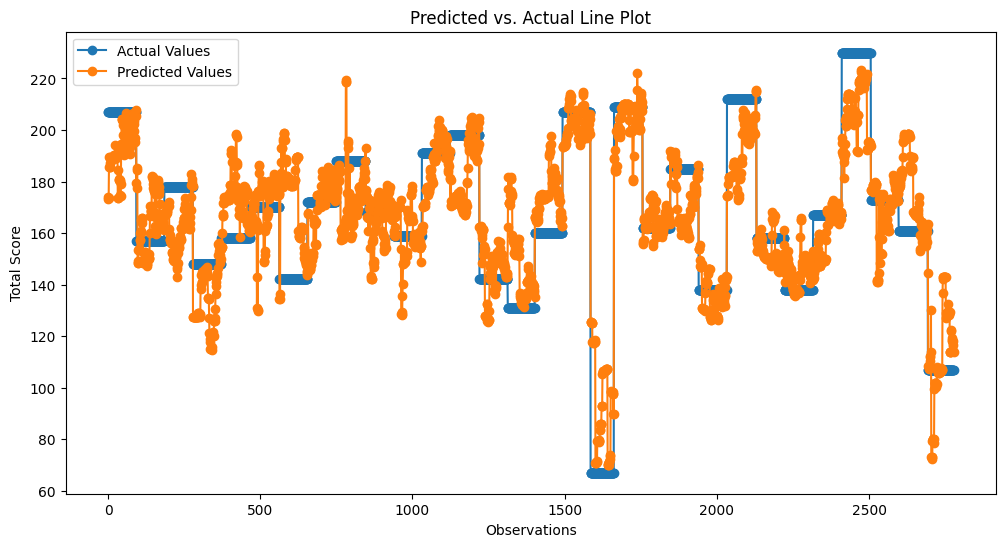

In [ ]:
# Line plot of predicted vs. actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Values', marker='o')
plt.plot(rf_predictions, label='Predicted Values', marker='o')
plt.title('Predicted vs. Actual Line Plot')
plt.xlabel('Observations')
plt.ylabel('Total Score')
plt.legend()
plt.show()

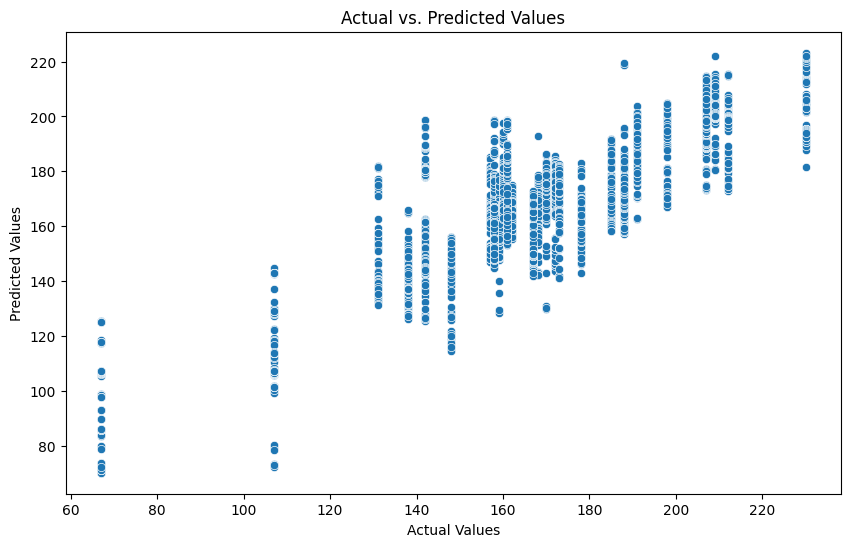

In [ ]:
# Scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=rf_predictions)
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

# **Xgboost**

In [ ]:
# Initialize and train XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
# Create the XGBoost regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Fit the model on the training data
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

In [ ]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)

Mean Squared Error: 280.5251159667969
Root Mean Squared Error (RMSE): 16.748884021534
Mean Absolute Error (MAE): 13.045576095581055
R2 Score: 0.7231308221817017


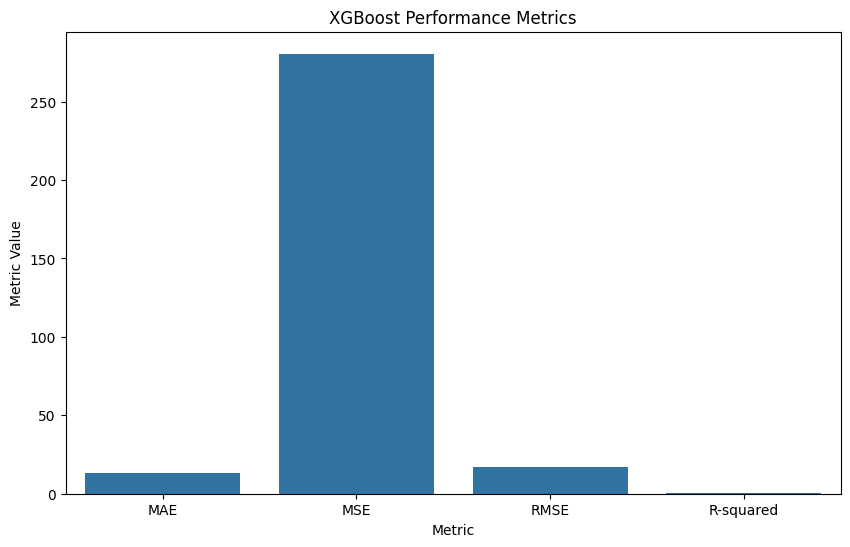

In [ ]:

# Optimize XGBoost Regression model by tuning learning_rate
learning_rates = [0.1]  # You can try more values like [0.01, 0.05, 0.1, 0.2]
best_rmse = float('inf')

for lr in learning_rates:
    # Initialize XGBoost Regression model with specified learning_rate
    xgb_reg = XGBRegressor(learning_rate=lr, n_estimators=100)

    # Train the model
    xgb_reg.fit(X_train, y_train)

    # Make Predictions on the test set
    xgb_predictions = xgb_reg.predict(X_test)

    # Evaluation metrics
    xgb_mae = mean_absolute_error(y_test, xgb_predictions)
    xgb_mse = mean_squared_error(y_test, xgb_predictions)
    xgb_rmse = np.sqrt(xgb_mse)
    xgb_r2 = r2_score(y_test, xgb_predictions)

    # Create a DataFrame for better visualization
    metrics_df = pd.DataFrame({
        'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
        'Value': [xgb_mae, xgb_mse, xgb_rmse, xgb_r2]
    })

    # Bar plot for performance metrics
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Metric', y='Value', data=metrics_df)
    plt.title('XGBoost Performance Metrics')
    plt.ylabel('Metric Value')
    plt.show()



In [ ]:
# Save the best model (based on lowest RMSE)
if xgb_rmse < best_rmse:
  best_rmse = xgb_rmse
  best_learning_rate = lr
  best_xgb_model = xgb_reg

print(f'\nBest XGBoost Model (learning_rate={best_learning_rate}):')
print(best_xgb_model)
# Save the best XGBoost model
best_xgb_model_filename = f'best_xgb_model_learning_rate_{best_learning_rate}.pkl'
pickle.dump(best_xgb_model, open(best_xgb_model_filename, 'wb'))

# Function to preprocess user input and make predictions
def predict_user_score(user_input, model, feature_columns):
    # Create a DataFrame with the user input
    user_df = pd.DataFrame([user_input])

    # Handle Categorical Variables in user input
    user_df_encoded = pd.get_dummies(data=user_df, columns=['bat_team', 'bowl_team'])

    # Ensure columns are consistent with feature_columns used during training
    user_df_encoded = user_df_encoded.reindex(columns=feature_columns, fill_value=0)

    # Make Predictions for the user input using the provided model
    user_predictions = model.predict(user_df_encoded)

    return user_predictions[0]


Best XGBoost Model (learning_rate=0.1):
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)


In [ ]:
# Example input values for user prediction
user_input = {
    'bat_team': 'Rajasthan Royals',
    'bowl_team': 'Mumbai Indians',
    'overs': 11,
    'runs': 108,
    'wickets': 2,
    'runs_last_5': 60,
    'wickets_last_5': 0
}

# Feature columns used during training
feature_columns = X_train.columns

# Make Predictions for the user input using the best XGBoost model
user_xgb_prediction = predict_user_score(user_input, best_xgb_model, feature_columns)

# Display the XGBoost prediction for the user input
print('\nXGBoost Predicted Score for User Input:', user_xgb_prediction)



XGBoost Predicted Score for User Input: 191.37823


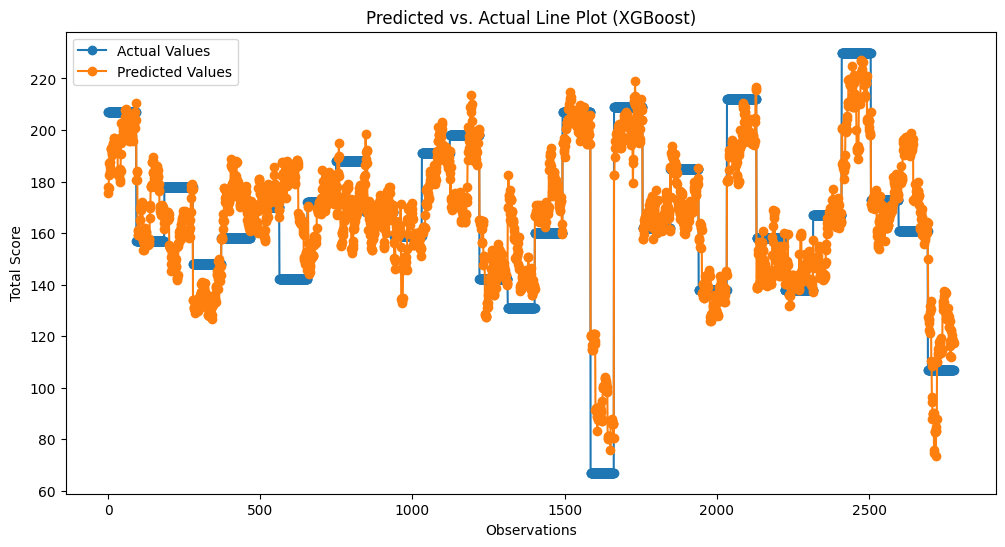

In [ ]:
# Line plot of predicted vs. actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Values', marker='o')
plt.plot(xgb_predictions, label='Predicted Values', marker='o')
plt.title('Predicted vs. Actual Line Plot (XGBoost)')
plt.xlabel('Observations')
plt.ylabel('Total Score')
plt.legend()
plt.show()


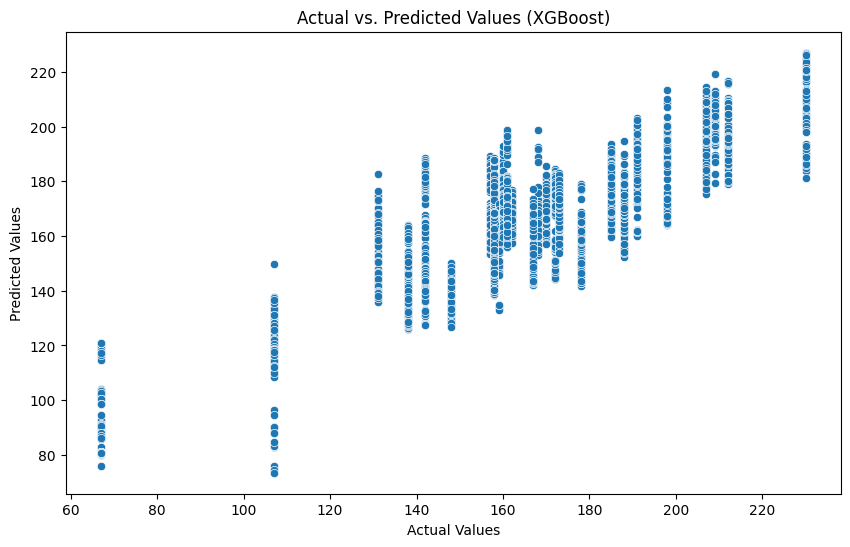

In [ ]:
# Scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=xgb_predictions)
plt.title('Actual vs. Predicted Values (XGBoost)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


In [ ]:
# Drop rows with missing values
df.dropna(inplace=True)

# Drop 'date' column if it exists (or convert it if needed)
if 'date' in df.columns:
    df.drop('date', axis=1, inplace=True)

# One-hot encode categorical variables
df = pd.get_dummies(df)

# Separate features and target
X = df.drop("total", axis=1)
y = df["total"]

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Convert a sequence of values into direction labels
def get_direction(prices):
    return [1 if prices[i] > prices[i - 1] else 0 for i in range(1, len(prices))]


In [ ]:
# Evaluate a regression model by comparing direction prediction
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Flatten and compute directions
    actual = y_test.values.flatten()
    predicted = y_pred.flatten()

    actual_direction = get_direction(actual)
    predicted_direction = get_direction(predicted)

    print(f"\n📊 Classification Report for {name}:")
    print(classification_report(actual_direction, predicted_direction, target_names=["Down", "Up"]))


In [ ]:
# Linear Regression
evaluate_model("Linear Regression", LinearRegression())

# Random Forest
evaluate_model("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42))

# XGBoost
evaluate_model("XGBoost", XGBRegressor(n_estimators=100, random_state=42))



📊 Classification Report for Linear Regression:
              precision    recall  f1-score   support

        Down       0.81      0.81      0.81      4027
          Up       0.81      0.81      0.81      3994

    accuracy                           0.81      8021
   macro avg       0.81      0.81      0.81      8021
weighted avg       0.81      0.81      0.81      8021


📊 Classification Report for Random Forest:
              precision    recall  f1-score   support

        Down       0.93      0.93      0.93      4027
          Up       0.93      0.93      0.93      3994

    accuracy                           0.93      8021
   macro avg       0.93      0.93      0.93      8021
weighted avg       0.93      0.93      0.93      8021


📊 Classification Report for XGBoost:
              precision    recall  f1-score   support

        Down       0.88      0.88      0.88      4027
          Up       0.88      0.88      0.88      3994

    accuracy                           0.88      802

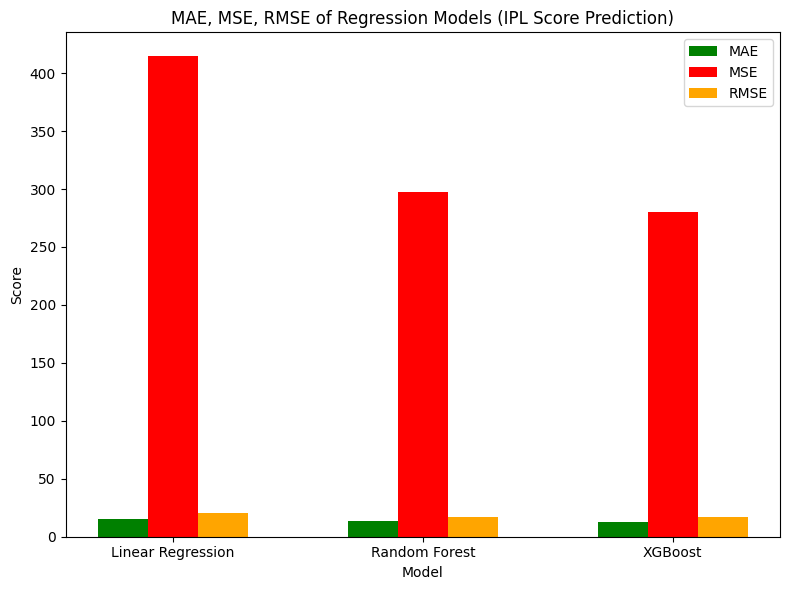

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Models
models = ['Linear Regression', 'Random Forest', 'XGBoost']

# Metric values
mae = [15.07, 13.14, 13.05]
mse = [414.50, 297.68, 280.53]
rmse = [20.36, 17.25, 16.75]

# Set up bar positions
x = np.arange(len(models))
width = 0.2

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width, mae, width, label='MAE', color='green')
ax.bar(x, mse, width, label='MSE', color='red')
ax.bar(x + width, rmse, width, label='RMSE', color='orange')

# Labeling
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('MAE, MSE, RMSE of Regression Models (IPL Score Prediction)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.tight_layout()
plt.show()


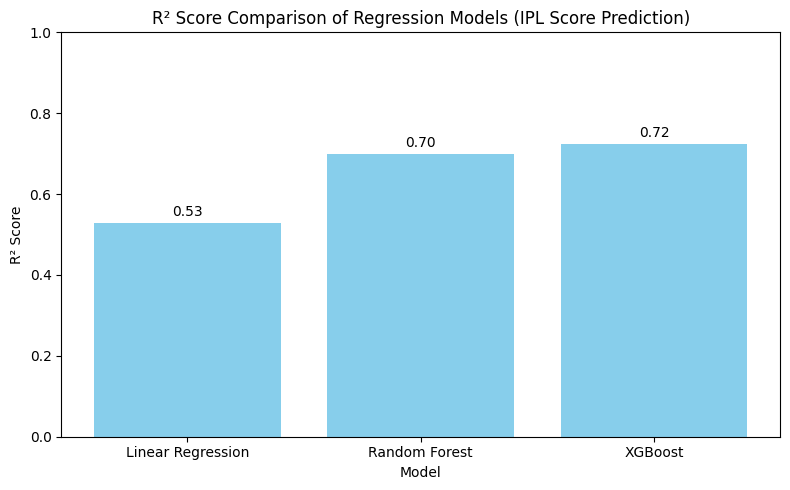

In [ ]:
# R2 Score values
r2_scores = [0.5285, 0.70, 0.7231]

# Plot R² separately
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color='skyblue')

# Set y-axis limit from 0 to 1
ax.set_ylim(0, 1)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}",
            ha='center', va='bottom', fontsize=10)

# Labels
ax.set_xlabel('Model')
ax.set_ylabel('R² Score')
ax.set_title('R² Score Comparison of Regression Models (IPL Score Prediction)')

plt.tight_layout()
plt.show()
